# Objetivo de Notebook

Esta notebook implementa un pipeline robusto para modelado no supervisado, separando claramente los datos de entrenamiento de los datos de evaluación, asegurando que el modelo no vea los mismos pozos/etapas que luego va a analizar.

## 🤖 Split Robusto y Modelado No Supervisado - CCL Anomalías

Esta notebook implementa:
- División del dataset por pozo y etapa.
- Entrenamiento del modelo (Isolation Forest) en runs seleccionadas.
- Evaluación del modelo en datos no vistos (evaluación visual de anomalías).
- Preparación de los resultados para visualización.

Esta estrategia permite evitar sobreajuste y simular condiciones de operación real.


### 💾 Celda 2 – Carga del dataset enriquecido

In [2]:
import pandas as pd

# Cargar dataset con features + CCL + TENS
df = pd.read_csv(r"C:\Developer\fundamentos\data\ccl_features.csv")
df = df.sort_values(by=["pozo", "etapa", "DEPT"]).reset_index(drop=True)

print(f"Total registros: {len(df)}")
df.head()


Total registros: 96780


,DEPT,CCL,TENS,archivo_origen,pozo,sentido,etapa,CCL_norm,dCCL,abs_dCCL,...,CCL_norm_mean_y,CCL_norm_std_y,CCL_norm_max_y,CCL_norm_min_y,abs_dCCL_mean_y,abs_dCCL_std_y,abs_dCCL_max_y,TENS_mean_y,TENS_std_y,TENS_max_y
0,2800.00,-0.00605,671.00007,BPE-2343_E36_Down__21Nov24_231144.las,BPE-2343,Down,E36,-1.210242,NaN,NaN,...,0.092022,4.046808,10.0,-9.998,1.982761,1.769662,19.087818,777.569303,62.48686,1266.38182
1,2800.05,0.01442,671.00007,BPE-2343_E36_Down__21Nov24_231144.las,BPE-2343,Down,E36,2.884577,4.094819,4.094819,...,0.092022,4.046808,10.0,-9.998,1.982761,1.769662,19.087818,777.569303,62.48686,1266.38182
2,2800.10,0.02212,663.99997,BPE-2343_E36_Down__21Nov24_231144.las,BPE-2343,Down,E36,4.424885,1.540308,1.540308,...,0.092022,4.046808,10.0,-9.998,1.982761,1.769662,19.087818,777.569303,62.48686,1266.38182
3,2800.15,0.01284,663.99997,BPE-2343_E36_Down__21Nov24_231144.las,BPE-2343,Down,E36,2.568514,-1.856371,1.856371,...,0.092022,4.046808,10.0,-9.998,1.982761,1.769662,19.087818,777.569303,62.48686,1266.38182
4,2800.20,-0.01889,663.81113,BPE-2343_E36_Down__21Nov24_231144.las,BPE-2343,Down,E36,-3.778756,-6.347269,6.347269,...,0.092022,4.046808,10.0,-9.998,1.982761,1.769662,19.087818,777.569303,62.48686,1266.38182


### 📋 Celda 3 – Generar resumen de etapas por pozo

In [3]:
df_summary = df[["pozo", "etapa"]].drop_duplicates().sort_values(["pozo", "etapa"])
print(f"Total de runs únicas: {len(df_summary)}")
df_summary.head(49)


Total de runs únicas: 4


,pozo,etapa
0,BPE-2343,E36
30542,BPE-2343,E38
59159,BPE-2343,E46
78888,BPE-2343,E48


### ✂️ Celda 4 – Split robusto por combinación pozo-etapa

In [5]:
# Definir manualmente qué pozo(s) y etapa(s) usar
train_seleccion = [
    ("BPE-2343", "E36"),
    ("BPE-2343", "E48"),
    ("BPE-2343", "E46"),
]

eval_seleccion = [
    ("BPE-2343", "E38"),
]

# Separar el dataset según las combinaciones seleccionadas
df_train = df[df[["pozo", "etapa"]].apply(tuple, axis=1).isin(train_seleccion)].copy()
df_eval = df[df[["pozo", "etapa"]].apply(tuple, axis=1).isin(eval_seleccion)].copy()

print(f"✅ Train: {df_train.shape[0]} registros en {len(train_seleccion)} runs")
print(f"✅ Eval:  {df_eval.shape[0]} registros en {len(eval_seleccion)} runs")

✅ Train: 68163 registros en 3 runs
✅ Eval:  28617 registros en 1 runs


### 🧠 Celda 5 – Entrenamiento con Isolation Forest

In [6]:
from sklearn.ensemble import IsolationForest

# Seleccionar features numéricas (excluimos DEPT y cualquier score anterior)
exclude = ["DEPT", "score_iso", "anomaly_iso"]
features_cols = [col for col in df_train.select_dtypes(include='number').columns if col not in exclude]


X_train = df_train[features_cols].fillna(0)
X_train_df = pd.DataFrame(X_train, columns=features_cols)
X_eval = df_eval[features_cols].fillna(0)

iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso.fit(X_train)

# Aplicar a evaluación
df_eval["score_iso"] = -iso.decision_function(X_eval)
df_eval["anomaly_iso"] = iso.predict(X_eval)  # -1 = anomalía, 1 = normal


#### ✅ A partir de IsolationForest — obtener importancia de features

IsolationForest es un modelo basado en árboles, por lo que sí permite extraer la importancia de cada variable directamente.

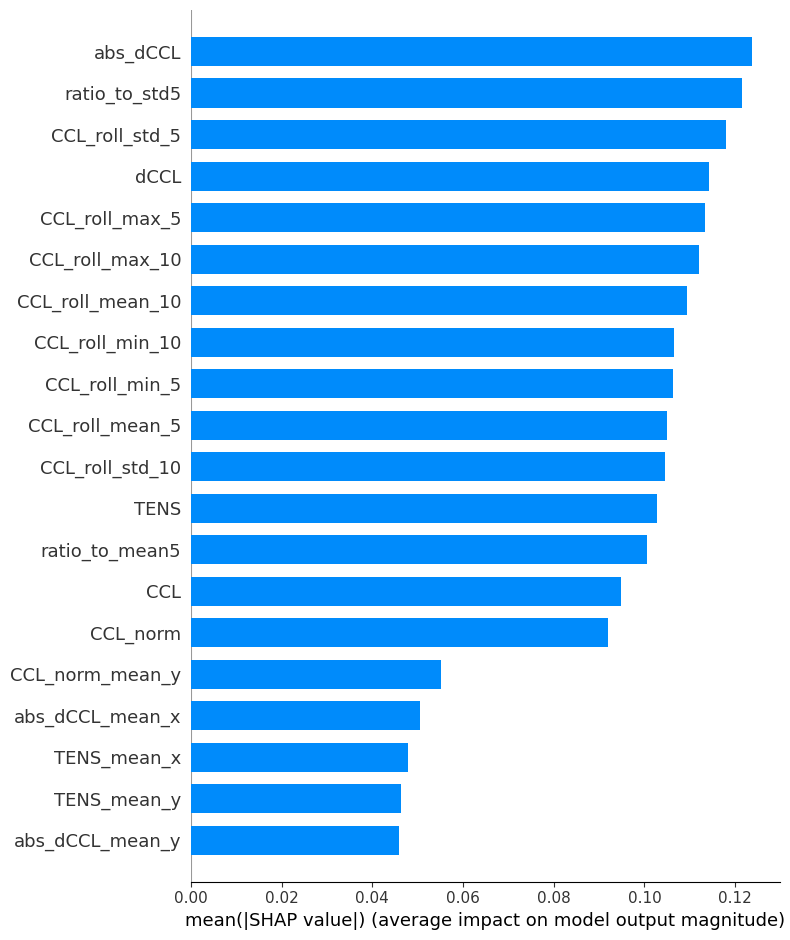

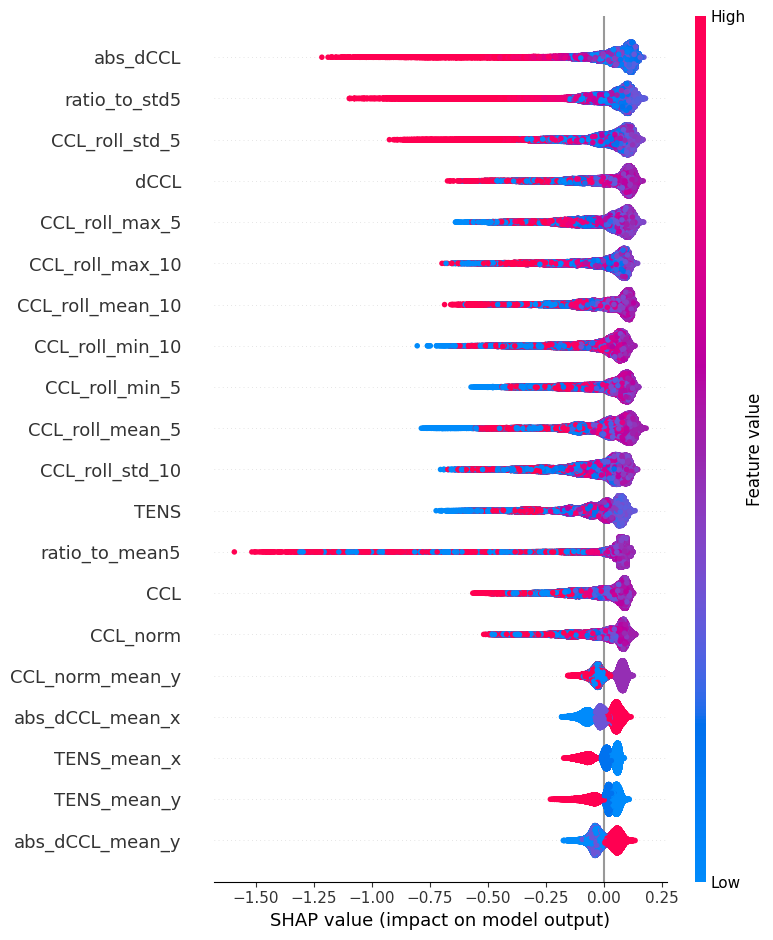

In [7]:
import shap

# Inicializar el TreeExplainer
explainer = shap.TreeExplainer(iso)

# Calcular los SHAP values
shap_values = explainer.shap_values(X_train_df)

# Gráfico de importancia (promedio de contribución)
shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=True)

# Gráfico de dispersión (más detalle por muestra)
shap.summary_plot(shap_values, X_train_df, show=True)



### 📦 Celda 6 – Guardar resultados de evaluación

In [5]:
df_eval.to_csv(r"C:\Developer\fundamentos\data\ccl_eval_scores.csv", index=False)
print("✅ Resultados de evaluación exportados a ccl_eval_scores.csv")


✅ Resultados de evaluación exportados a ccl_eval_scores.csv


### 📊 Celda 7 – Vista rápida de anomalías detectadas

In [6]:
anomalias_por_etapa = df_eval[df_eval["anomaly_iso"] == -1].groupby(["pozo", "etapa"]).size().reset_index(name="anomalías")
anomalias_por_etapa.sort_values("anomalías", ascending=False).head(10)


,pozo,etapa,anomalías
0,BPE-2343,E38,1980
